<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex%2Fgame-dynamics-dtb/DTB_Game_Ver2/oscillatory_accumulated_map_parameter_evolving_dtb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Oscillatory DTB with simultaneous accumulated-map and parameter evolution

This notebook implements two coupled but distinct states. The accumulated physical map \(X_k\) follows projected tangent velocities, while \(T_{\theta_k}\) evolves only to provide a new parameter-tangent basis at the next step. There is no diffusion, density, or score term.

Initialize \(X_0(z)=T_{\theta_0}(z)\). At physical step \(k\), compute

\[
x_i^k=X_k(z_i),\qquad
J_i^k=D_\theta T_{\theta_k}(z_i),
\]

\[
\alpha_k=\arg\min_\alpha\sum_i\|J_i^k\alpha-b(x_i^k)\|^2,
\]

and then update both states with the same coefficient vector:

\[
X_{k+1}(z)=X_k(z)+hD_\theta T_{\theta_k}(z)\alpha_k,\qquad
\theta_{k+1}=\theta_k+h\alpha_k.
\]

Therefore \(X_k(z)=T_{\theta_0}(z)+h\sum_{j<k}D_\theta T_{\theta_j}(z)\alpha_j\). Crucially, the physical state is **not** overwritten by \(T_{\theta_{k+1}}\). The notebook measures their growing gap explicitly. The least-squares solve reuses the repository's restricted Jacobian and truncated-SVD utilities.

In [13]:
# BLOCK 0 — Colab/repository setup and experiment controls.
# Change values only in the configuration section when starting a sweep.
from pathlib import Path
import os, subprocess, sys, math, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.func import jacrev, vmap

REPO = Path("/content/dtb-colab-experiments")
BRANCH = "codex/game-dynamics-dtb"
if not (REPO / ".git").exists():
    subprocess.run(["git", "clone", "-q", "--depth", "1", "--branch", BRANCH,
                    "https://github.com/sun-mengwei/dtb-colab-experiments.git", str(REPO)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO), "checkout", "-q", BRANCH], check=True)
    subprocess.run(["git", "-C", str(REPO), "pull", "-q", "--ff-only"], check=True)
EXPERIMENT_DIR = REPO / "DTB_Game_Ver2"
sys.path.insert(0, str(EXPERIMENT_DIR))
sys.path.insert(0, str(REPO / "DTB_Game_Ver1"))
os.chdir(EXPERIMENT_DIR)

try:
    import torch._dynamo.compiled_autograd
except (AttributeError, ImportError):
    pass
from dtb import device, flat_params, write_flat_into_model
from run_game_dtb import ResidualMLPMap, game_dtb_basis_matrices, map_at
from game_dtb.projection import truncated_svd_solve

# --------------------------- configuration ---------------------------
SEED = 2026
N = 1000
T, H = 1.0, 0.005
K = round(T / H)
WIDTH, DEPTH = 16, 2
SVD_RTOL = 1e-3  # filters parameter directions below rtol * sigma_max
JACOBIAN_CHUNK = 128
ACCUMULATION_CHECK_INTERVAL = 20  # reconstruct X_k(z) from all saved terms
DOMAIN_LOW, DOMAIN_HIGH = -1.0, 1.0
DIRECTION_NORM_TOL = 1e-8
LAMBDA, GAMMA = 0.5, 0.2
EPSILON, OMEGA = 0.5, 4 * math.pi
SNAPSHOT_STEPS = sorted(set([0, K // 4, K // 2, 3 * K // 4, K]))

DEVICE = device()
DTYPE = torch.float32
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")
print({"device": str(DEVICE), "particles": N, "steps": K, "h": H,
       "svd_rtol": SVD_RTOL})

{'device': 'cuda', 'particles': 1000, 'steps': 200, 'h': 0.005, 'svd_rtol': 0.001}


In [14]:
# BLOCK 1 — Define the exact oscillatory deterministic game.
def phi(x):
    """Potential used for phase-plane contours and energy diagnostics."""
    x1, x2 = x.unbind(-1)
    return (
        -0.5 * LAMBDA * (x1.square() + x2.square())
        -0.5 * GAMMA * (x1 - x2).square()
        +(EPSILON / OMEGA) * (torch.cos(OMEGA * x1) + torch.cos(OMEGA * x2))
    )

def b(x):
    """Simultaneous payoff-gradient velocity b(x)=grad Phi(x)."""
    x1, x2 = x.unbind(-1)
    return torch.stack((
        -LAMBDA * x1 - GAMMA * (x1 - x2) - EPSILON * torch.sin(OMEGA * x1),
        -LAMBDA * x2 - GAMMA * (x2 - x1) - EPSILON * torch.sin(OMEGA * x2),
    ), dim=-1)

# Exact implementation check: b must equal grad Phi.
check_x = torch.tensor([[0.17, -0.31]], device=DEVICE, dtype=DTYPE, requires_grad=True)
assert (torch.autograd.grad(phi(check_x).sum(), check_x)[0] - b(check_x)).abs().max() < 2e-6

In [15]:
# BLOCK 2 — Sample fixed labels and initialize X_0=T_{theta_0}=identity.
# The labels z_i never change; X_k and T_{theta_k} evolve separately afterward.
z = (DOMAIN_LOW + (DOMAIN_HIGH - DOMAIN_LOW)
     * torch.rand(N, 2, dtype=DTYPE)).to(DEVICE)
model = ResidualMLPMap(dim=2, width=WIDTH, depth=DEPTH,
                       activation="tanh", dtype=DTYPE).to(DEVICE)
theta_0, structure, _ = flat_params(model)
theta_0 = theta_0.to(DEVICE)
selected = torch.arange(theta_0.numel(), device=DEVICE)  # evolve every parameter
x0 = map_at(theta_0, z, model, structure).detach()
assert torch.allclose(x0, z, atol=1e-7, rtol=0), "residual map must start at identity"
print(f"trainable parameters: {theta_0.numel()} (all used in the SVD solve)")

trainable parameters: 354 (all used in the SVD solve)


In [16]:
# BLOCK 3 — Helpers, the accumulated-map object, and the coupled loop.
def particle_direction_cosine(projected_velocity, target_velocity, tol=DIRECTION_NORM_TOL):
    """Cosine alignment for each particle; near-zero vectors return NaN."""
    projected_norm = torch.linalg.vector_norm(projected_velocity, dim=1)
    target_norm = torch.linalg.vector_norm(target_velocity, dim=1)
    valid = (projected_norm > tol) & (target_norm > tol)
    cosine = torch.full_like(projected_norm, float("nan"))
    cosine[valid] = (
        (projected_velocity[valid] * target_velocity[valid]).sum(1)
        / (projected_norm[valid] * target_norm[valid])
    ).clamp(-1, 1)
    return cosine

def map_conditioning(theta_k, labels):
    """Return sampled |det D_z f_theta| and condition numbers.

    These quantities do not enter the deterministic algorithm. They only
    warn when direct parameter evolution makes the pushforward map fold.
    """
    theta_constant = theta_k.detach().clone()

    def map_one(z_one):
        return map_at(theta_constant, z_one.unsqueeze(0), model, structure).squeeze(0)

    map_jacobians = vmap(jacrev(map_one))(labels)
    return torch.linalg.det(map_jacobians).abs(), torch.linalg.cond(map_jacobians)

class AccumulatedMovingTangentMap:
    """Callable X_k(z)=T_theta0(z)+h*sum_{j<k} J_thetaj(z) alpha_j."""
    def __init__(self, theta_initial):
        self.theta_initial = theta_initial.detach().clone()
        self.terms = []

    def append(self, theta_k, alpha_k):
        """Save one moving-basis contribution without retaining autograd graphs."""
        self.terms.append((theta_k.detach().clone(), alpha_k.detach().clone()))

    def __call__(self, labels):
        """Evaluate the full accumulated map on any requested labels."""
        values = map_at(self.theta_initial, labels, model, structure).detach()
        for theta_j, alpha_j in self.terms:
            _, jacobians_j, _ = game_dtb_basis_matrices(
                theta_j, selected, labels, model, structure, chunk=JACOBIAN_CHUNK
            )
            values = values + H * torch.einsum("ndm,m->nd", jacobians_j, alpha_j)
        return values.detach()

def run_coupled_map_parameter_dtb(theta_initial, labels):
    """Evolve accumulated X_k and basis parameters theta_k simultaneously."""
    theta_k = theta_initial.detach().clone()
    network_k = map_at(theta_k, labels, model, structure).detach()
    x_k = network_k.clone()  # X_0=T_theta0 only at initialization.
    accumulated_map = AccumulatedMovingTangentMap(theta_k)
    history = {name: [] for name in (
        "trajectory", "network_trajectory",
        "network_tangent_prediction_trajectory", "projection_residual",
        "retained_rank", "sigma_max", "sigma_min_retained",
        "alpha_norm", "fraction_negative", "fraction_above_half",
        "physical_network_gap", "network_curvature_error",
        "accumulation_reconstruction_error",
        "min_abs_network_det", "max_network_condition",
    )}
    history["trajectory"].append(x_k.cpu())
    history["network_trajectory"].append(network_k.cpu())
    history["network_tangent_prediction_trajectory"].append(network_k.cpu())
    tic = time.perf_counter()

    for k in range(K):
        # BLOCK 3A — Use T_theta_k only to generate the current tangent basis.
        network_k, jacobians, stacked_jacobian = game_dtb_basis_matrices(
            theta_k, selected, labels, model, structure, chunk=JACOBIAN_CHUNK
        )
        network_k = network_k.detach()

        # BLOCK 3B — Evaluate the game at the independent accumulated state X_k.
        target_velocity = b(x_k)

        # BLOCK 3C — Project b(X_k) onto the moving basis J_theta_k.
        alpha_k, svd = truncated_svd_solve(
            stacked_jacobian, target_velocity.reshape(-1), rtol=SVD_RTOL
        )
        tangent_velocity = torch.einsum("ndm,m->nd", jacobians, alpha_k)
        cosine = particle_direction_cosine(tangent_velocity, target_velocity)
        valid = torch.isfinite(cosine)

        # BLOCK 3D — Apply the same alpha_k to two different state updates.
        x_next = x_k + H * tangent_velocity.detach()
        theta_next = theta_k + H * alpha_k
        network_next = map_at(theta_next, labels, model, structure).detach()
        accumulated_map.append(theta_k, alpha_k)

        # BLOCK 3E — Separate nonlinear parameter curvature from map accumulation.
        network_tangent_prediction = network_k + H * tangent_velocity.detach()
        network_curvature_error = torch.sqrt(torch.mean(torch.sum(
            (network_next - network_tangent_prediction).square(), dim=1
        )))
        physical_network_gap = torch.sqrt(torch.mean(torch.sum(
            (x_next - network_next).square(), dim=1
        )))
        abs_det, condition = map_conditioning(theta_k, labels)

        # Periodically reconstruct the callable sum to verify the O(1) particle update.
        reconstruction_error = float("nan")
        if (k + 1) % ACCUMULATION_CHECK_INTERVAL == 0 or k + 1 == K:
            reconstructed = accumulated_map(labels)
            reconstruction_error = float(torch.sqrt(torch.mean(torch.sum(
                (reconstructed - x_next).square(), dim=1
            ))))
            assert reconstruction_error < 2e-4, "accumulated map reconstruction failed"

        # BLOCK 3F — Store both map histories and all interpretation diagnostics.
        history["trajectory"].append(x_next.cpu())
        history["network_trajectory"].append(network_next.cpu())
        history["network_tangent_prediction_trajectory"].append(
            network_tangent_prediction.cpu()
        )
        history["projection_residual"].append(svd.relative_residual)
        history["retained_rank"].append(svd.retained_rank)
        history["sigma_max"].append(svd.sigma_max)
        history["sigma_min_retained"].append(svd.sigma_min_retained)
        history["alpha_norm"].append(float(torch.linalg.norm(alpha_k)))
        history["fraction_negative"].append(float((cosine[valid] < 0).float().mean()))
        history["fraction_above_half"].append(float((cosine[valid] > 0.5).float().mean()))
        history["physical_network_gap"].append(float(physical_network_gap))
        history["network_curvature_error"].append(float(network_curvature_error))
        history["accumulation_reconstruction_error"].append(reconstruction_error)
        history["min_abs_network_det"].append(float(abs_det.min()))
        history["max_network_condition"].append(float(condition.max()))

        x_k, theta_k = x_next.detach(), theta_next.detach()
        if (k + 1) % max(1, K // 5) == 0:
            print(f"{k + 1:3d}/{K}: residual={svd.relative_residual:.2e}, "
                  f"|alpha|={float(alpha_k.norm()):.2e}, "
                  f"|X-T_theta|={float(physical_network_gap):.2e}")

    write_flat_into_model(model, theta_k, structure)
    history["trajectory"] = torch.stack(history["trajectory"])
    history["network_trajectory"] = torch.stack(history["network_trajectory"])
    history["network_tangent_prediction_trajectory"] = torch.stack(
        history["network_tangent_prediction_trajectory"]
    )
    for key in history:
        if key not in ("trajectory", "network_trajectory",
                       "network_tangent_prediction_trajectory"):
            history[key] = np.asarray(history[key])
    history["wall_seconds"] = time.perf_counter() - tic
    return theta_k, accumulated_map, history

In [17]:
# BLOCK 4 — Build the paired Euler reference and run the proposed workflow.
# Euler follows the same fixed labels and h, but uses the exact b(X_k).
x_reference = z.detach().clone()
reference_trajectory = [x_reference.cpu()]
for _ in range(K):
    x_reference = x_reference + H * b(x_reference)
    reference_trajectory.append(x_reference.detach().cpu())
reference_trajectory = torch.stack(reference_trajectory)

theta_K, X_K_map, result = run_coupled_map_parameter_dtb(theta_0, z)
assert torch.isfinite(theta_K).all() and torch.isfinite(result["trajectory"]).all()
assert torch.isfinite(result["network_trajectory"]).all()
assert torch.isfinite(result["network_tangent_prediction_trajectory"]).all()
assert result["trajectory"].shape == reference_trajectory.shape
assert result["network_trajectory"].shape == reference_trajectory.shape
assert result["network_tangent_prediction_trajectory"].shape == reference_trajectory.shape

trajectory_rmse = torch.sqrt(torch.mean(torch.sum(
    (result["trajectory"] - reference_trajectory).square(), dim=-1
), dim=1))
reference_rms = torch.sqrt(torch.mean(torch.sum(reference_trajectory.square(), dim=-1), dim=1))
relative_rmse = trajectory_rmse / (reference_rms + 1e-12)
network_rmse = torch.sqrt(torch.mean(torch.sum(
    (result["network_trajectory"] - reference_trajectory).square(), dim=-1
), dim=1))
network_relative_rmse = network_rmse / (reference_rms + 1e-12)
tangent_prediction_rmse = torch.sqrt(torch.mean(torch.sum(
    (result["network_tangent_prediction_trajectory"] - reference_trajectory).square(), dim=-1
), dim=1))
potential_reference = phi(reference_trajectory).mean(1)
potential_accumulated = phi(result["trajectory"]).mean(1)
potential_network = phi(result["network_trajectory"]).mean(1)
potential_tangent_prediction = phi(
    result["network_tangent_prediction_trajectory"]
).mean(1)

print(f"wall time: {result['wall_seconds']:.1f} s")
print(f"mean/max residual: {result['projection_residual'].mean():.3e} / "
      f"{result['projection_residual'].max():.3e}")
print(f"final accumulated-X RMSE: {trajectory_rmse[-1]:.3e}; "
      f"relative {relative_rmse[-1]:.3e}")
print(f"final neural-map RMSE: {network_rmse[-1]:.3e}; "
      f"relative {network_relative_rmse[-1]:.3e}")
print(f"final tangent-prediction RMSE: {tangent_prediction_rmse[-1]:.3e}")
print(f"final ||X_K-T_thetaK|| RMSE: {result['physical_network_gap'][-1]:.3e}")

 40/200: residual=7.15e-01, |alpha|=1.88e+01, |X-T_theta|=1.31e-02
 80/200: residual=5.78e-01, |alpha|=2.95e+01, |X-T_theta|=1.01e-02
120/200: residual=6.61e-01, |alpha|=1.38e+01, |X-T_theta|=1.56e-02
160/200: residual=8.28e-01, |alpha|=9.68e+00, |X-T_theta|=2.55e-02
200/200: residual=6.86e-01, |alpha|=3.01e+01, |X-T_theta|=1.90e-02
wall time: 50.2 s
mean/max residual: 7.051e-01 / 8.563e-01
final accumulated-X RMSE: 2.223e-01; relative 3.685e-01
final neural-map RMSE: 2.200e-01; relative 3.646e-01
final tangent-prediction RMSE: 2.202e-01
final ||X_K-T_thetaK|| RMSE: 1.901e-02


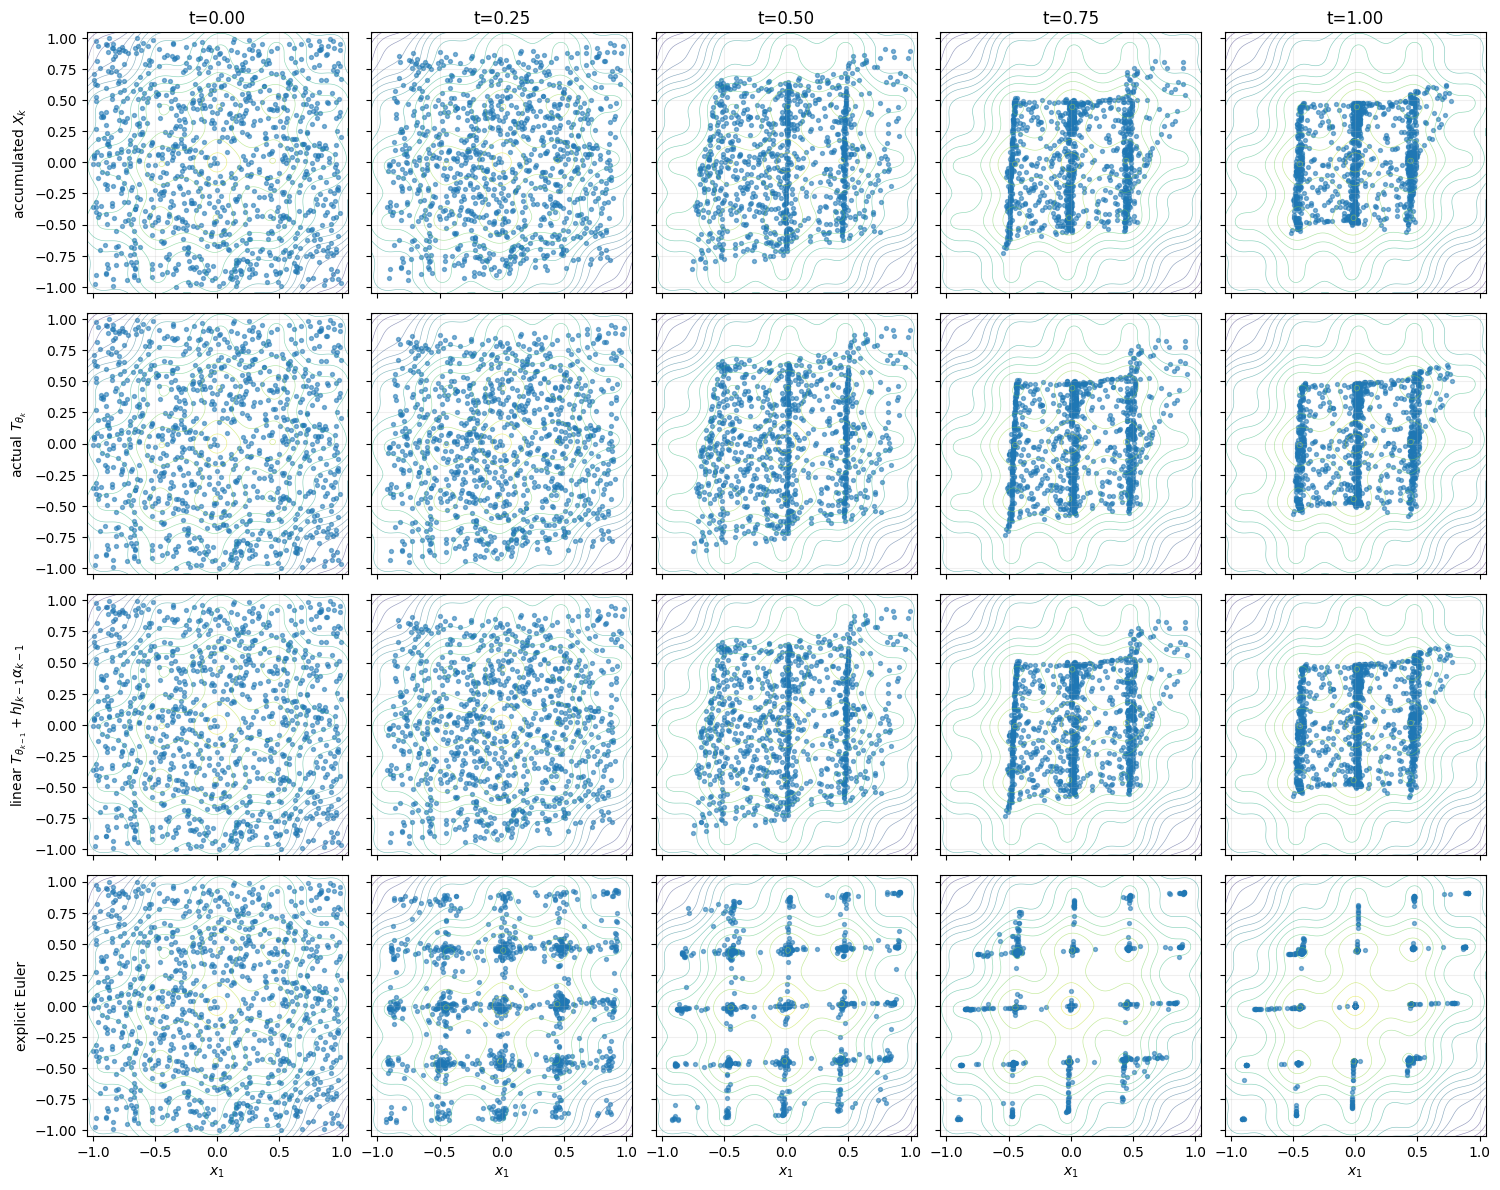

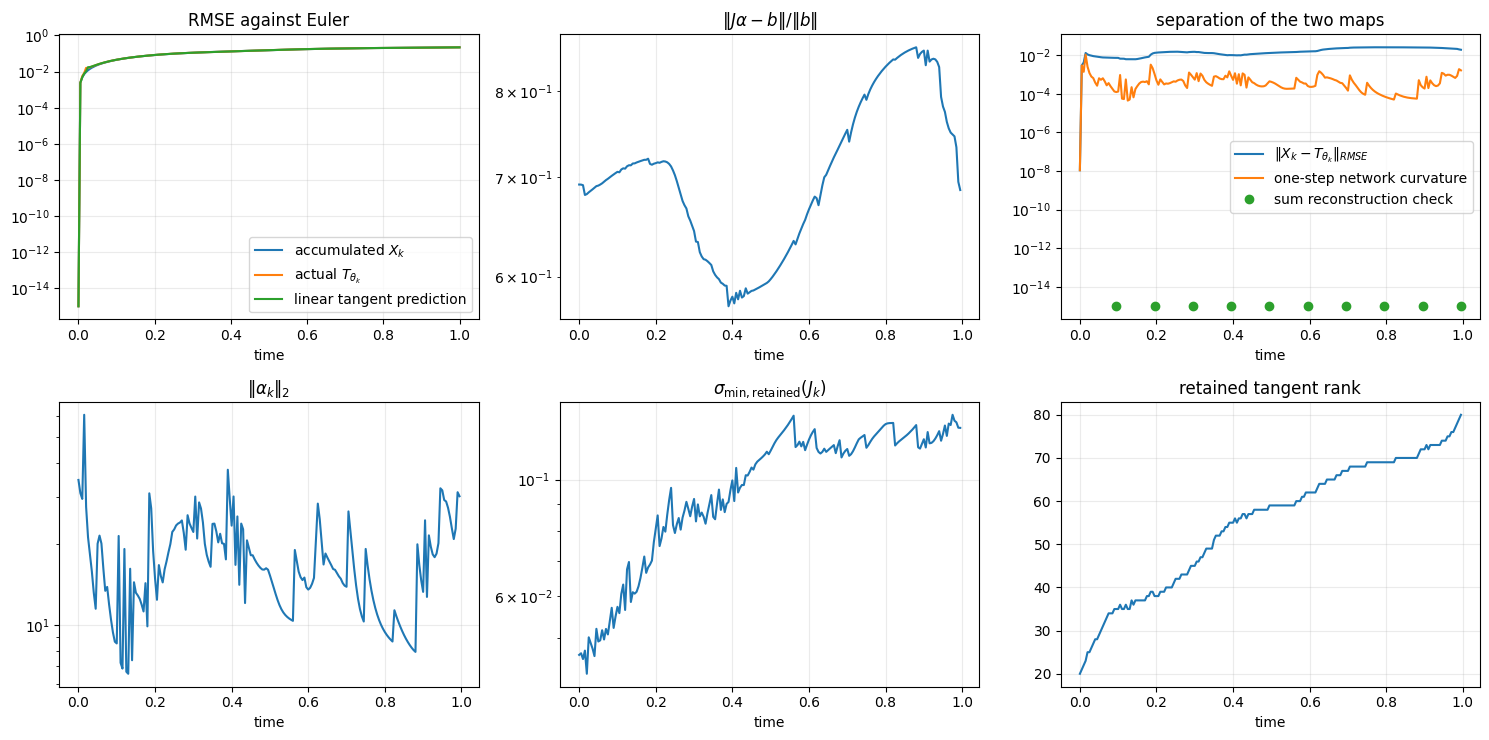

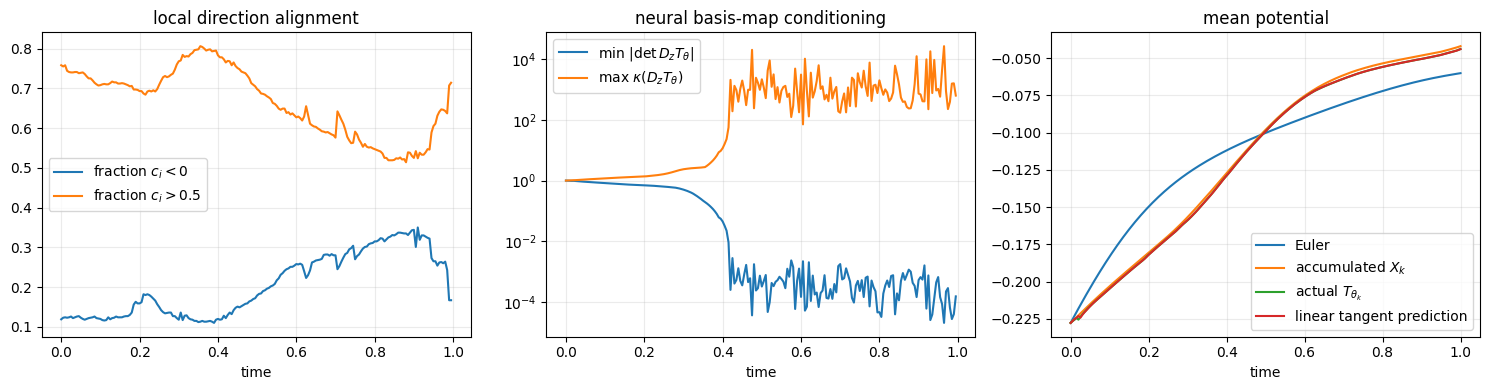

In [18]:
# BLOCK 5 — Compare accumulated X_k, neural T_theta_k, and explicit Euler.
grid_axis = torch.linspace(-1.05, 1.05, 140)
grid_x1, grid_x2 = torch.meshgrid(grid_axis, grid_axis, indexing="xy")
potential_grid = phi(torch.stack((grid_x1.ravel(), grid_x2.ravel()), -1)).reshape(grid_x1.shape)
fig, axes = plt.subplots(4, len(SNAPSHOT_STEPS), figsize=(3 * len(SNAPSHOT_STEPS), 12),
                         sharex=True, sharey=True)
for column, step in enumerate(SNAPSHOT_STEPS):
    for row in range(4):
        axes[row, column].contour(grid_x1, grid_x2, potential_grid, levels=16,
                                  linewidths=.45, alpha=.55)
    accumulated_points = result["trajectory"][step].numpy()
    network_points = result["network_trajectory"][step].numpy()
    tangent_prediction_points = result["network_tangent_prediction_trajectory"][step].numpy()
    ref_points = reference_trajectory[step].numpy()
    axes[0, column].scatter(accumulated_points[:, 0], accumulated_points[:, 1], s=8, alpha=.55)
    axes[1, column].scatter(network_points[:, 0], network_points[:, 1], s=8, alpha=.55)
    axes[2, column].scatter(tangent_prediction_points[:, 0], tangent_prediction_points[:, 1], s=8, alpha=.55)
    axes[3, column].scatter(ref_points[:, 0], ref_points[:, 1], s=8, alpha=.55)
    axes[0, column].set_title(f"t={step * H:.2f}")
    for row in range(4):
        axes[row, column].grid(alpha=.2); axes[row, column].set_aspect("equal")
axes[0, 0].set_ylabel(r"accumulated $X_k$")
axes[1, 0].set_ylabel(r"actual $T_{\theta_k}$")
axes[2, 0].set_ylabel(r"linear $T_{\theta_{k-1}}+hJ_{k-1}\alpha_{k-1}$")
axes[3, 0].set_ylabel("explicit Euler")
for axis in axes[3]: axis.set_xlabel(r"$x_1$")
plt.tight_layout(); plt.show()

state_times = np.arange(K + 1) * H
step_times = np.arange(K) * H
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
axes[0, 0].semilogy(state_times, trajectory_rmse + 1e-15, label=r"accumulated $X_k$")
axes[0, 0].semilogy(state_times, network_rmse + 1e-15, label=r"actual $T_{\theta_k}$")
axes[0, 0].semilogy(state_times, tangent_prediction_rmse + 1e-15,
                     label="linear tangent prediction")
axes[0, 0].set_title("RMSE against Euler"); axes[0, 0].legend()
axes[0, 1].semilogy(step_times, result["projection_residual"] + 1e-15)
axes[0, 1].set_title(r"$\|J\alpha-b\|/\|b\|$")
axes[0, 2].semilogy(step_times, result["physical_network_gap"] + 1e-15,
                     label=r"$\|X_k-T_{\theta_k}\|_{RMSE}$")
axes[0, 2].semilogy(step_times, result["network_curvature_error"] + 1e-15,
                     label="one-step network curvature")
checked = np.isfinite(result["accumulation_reconstruction_error"])
axes[0, 2].semilogy(step_times[checked],
                     result["accumulation_reconstruction_error"][checked] + 1e-15,
                     "o", label="sum reconstruction check")
axes[0, 2].set_title("separation of the two maps"); axes[0, 2].legend()
axes[1, 0].semilogy(step_times, result["alpha_norm"] + 1e-15)
axes[1, 0].set_title(r"$\|\alpha_k\|_2$")
axes[1, 1].semilogy(step_times, result["sigma_min_retained"] + 1e-15)
axes[1, 1].set_title(r"$\sigma_{\min,\mathrm{retained}}(J_k)$")
axes[1, 2].plot(step_times, result["retained_rank"])
axes[1, 2].set_title("retained tangent rank")
for axis in axes.ravel():
    axis.set_xlabel("time"); axis.grid(alpha=.25)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(step_times, result["fraction_negative"], label=r"fraction $c_i<0$")
axes[0].plot(step_times, result["fraction_above_half"], label=r"fraction $c_i>0.5$")
axes[0].set_title("local direction alignment"); axes[0].legend()
axes[1].semilogy(step_times, result["min_abs_network_det"] + 1e-15, label=r"min $|\det D_zT_\theta|$")
axes[1].semilogy(step_times, result["max_network_condition"] + 1e-15, label=r"max $\kappa(D_zT_\theta)$")
axes[1].set_title("neural basis-map conditioning"); axes[1].legend()
axes[2].plot(state_times, potential_reference, label="Euler")
axes[2].plot(state_times, potential_accumulated, label=r"accumulated $X_k$")
axes[2].plot(state_times, potential_network, label=r"actual $T_{\theta_k}$")
axes[2].plot(state_times, potential_tangent_prediction,
             label="linear tangent prediction")
axes[2].set_title("mean potential"); axes[2].legend()
for axis in axes:
    axis.set_xlabel("time"); axis.grid(alpha=.25)
plt.tight_layout(); plt.show()

## Reading the coupled-map trial

- `projection_residual` measures how well the moving neural tangent basis represents \(b(X_k)\), evaluated at the independent accumulated physical state.
- `physical_network_gap` is the central new diagnostic: it measures how far the accumulated \(X_k\) has separated from \(T_{\theta_k}\).
- The phase portrait stores the actual nonlinear update \(T_{\theta_k+h\alpha_k}\) separately from the linear prediction \(T_{\theta_k}+hD_\theta T_{\theta_k}\alpha_k\). At plotted time index \(k>0\), these appear as \(T_{\theta_k}\) and the prediction made from step \(k-1\).
- `network_curvature_error` is the paired RMSE between those two maps and therefore isolates nonlinear parameter curvature.
- `accumulation_reconstruction_error` verifies periodically that the fast particle update equals the explicit callable sum of all moving-basis contributions.
- A small retained singular value can amplify \(\alpha_k\); compare both plots rather than interpreting either alone.
- Neural determinant and condition diagnostics concern the basis-generating \(T_{\theta_k}\), not the independently accumulated \(X_k\).
- The explicit-Euler reference uses the same \(h\), so the accumulated-map error primarily measures tangent projection rather than a mismatch of time integrators.